# Melbourne Weather Code Workflow

## Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
melb = pd.read_csv("Melbourne01.csv",low_memory=False,on_bad_lines="skip")


In [3]:
melb.columns = ['Year', 'Month', 'Day', 'Hour', 'Min', 'Air Temp (degrees C)',
       'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
       'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)']

In [4]:
melb_str = melb[melb["Month"].map(type) == str]

melb["Year"].value_counts()

2015                                                                   120022
2016                                                                    93673
2020                                                                    93243
2017                                                                    93159
2019                                                                    93102
                                                                        ...  
2015\t05\t14\t22\t00\t12.8\t11.7\t12\t95\tSW\t19\t24\t1034.1\t0.6           1
2015\t05\t14\t22\t30\t12.5\t11.8\t11.9\t96\tWSW\t17\t24\t1034\t0.6          1
2015\t05\t14\t23\t00\t12.3\t11.8\t12\t98\tSW\t19\t24\t1034\t0.8             1
2015\t05\t14\t23\t30\t12.1\t11.3\t11.8\t98\tSW\t19\t22\t1034.1\t0.8         1
2017\t8\t30\t17\t00\t11.9\t8.4\t3.4\t50\tS\t22\t30\t1028.8\t0.2\t           1
Name: Year, Length: 631, dtype: int64

In [5]:
tabbed_months = melb_str["Month"].unique()[12:28]

In [6]:
melb = melb.astype("object")
n_position = 580364
for month in tabbed_months:
    month = month.split("\t")
    empty_first = [""] + month
    row = pd.Series(empty_first)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row= row.to_list()
    melb.loc[n_position] = row
    melb.iloc[n_position,0] = 2017
    n_position +=1


    # month = month.split("\t")

    # row = ["2017"] + month   # keep raw values first

    # melb.loc[n_position] = row  # insert raw row first

    # n_position += 1
# melb = melb.apply(pd.to_numeric, errors="coerce")
# rows = []

# for month in tabbed_months:
#     parts = month.split("\t")
#     row = ["2017"] + parts
#     rows.append(row)


# new_df = pd.DataFrame(rows)


# new_df.columns = melb.columns
# melb = pd.concat([melb, new_df], ignore_index=True)

# melb = melb.sort_values(by=["Year", "Month", "Day", "Hour", "Min"])
# melb = melb.reset_index(drop=True)

In [7]:
fix_year = melb[melb['Month'].isna()].loc[::,"Year"]
indices = melb[melb['Month'].isna()].index.to_list()

In [8]:
y_position = 0
for year in fix_year:
    year = year.strip()
    year = year.split("\t")
    # row = pd.to_numeric(pd.Series(year), errors = 'ignore').to_list()

    row = pd.Series(year)
    try:
        row = pd.to_numeric(row)
    except ValueError:
        pass
    row=row.to_list()
    
    y_ind = indices[y_position]
    melb.loc[y_ind] = row
    y_position +=1

In [9]:
melb["Year"].value_counts()

2015    120194
2016     93673
2020     93365
2017     93184
2018     93156
2014     93155
2019     93112
2013     90510
2011     89961
2012     88409
2022     66410
2021     53589
2024     21509
2023     17818
2025      5090
2017        16
Name: Year, dtype: int64

In [10]:
melb["Day"] = melb["Day"].astype(int, errors = 'ignore')

In [11]:
melb["Year"] = melb["Year"].astype(int)

In [12]:
replace_month = {' 1': 1,
                 ' 2': 2,
                 ' 3': 3,
                 ' 4': 4,
                 ' 5': 5,
                 ' 6': 6,
                 ' 7': 7,
                 ' 8': 8,
                 ' 9': 9,
                 ' 10': 10,
                 ' 11': 11,
                 ' 12': 12,
                 ' 06': 6,
                 ' 03': 3,
                 ' 04': 4,
                 ' 05': 5,
                 ' 07': 7,
                 ' 08': 8,
                 ' 09': 9,
                 ' 01': 1,
                 ' 02': 2,
                 '09': 9,
                 '05': 5,
                 '02': 2,
                 '08': 8,
                 '1': 1,
                 '6': 6,
                 '8': 8,
                 '7': 7,
                 '5': 5,
                 '11':11
                }

In [13]:
melb["Month"] = melb["Month"].replace(replace_month)

In [14]:
replace_hour = {'06': 6,
                 '03': 3,
                 '04': 4,
                 '05': 5,
                 '07': 7,
                 '08': 8,
                 '09': 9,
                 '01': 1,
                 '02': 2,
                '00': 0
                }

In [15]:
melb["Hour"] = melb["Hour"].replace(replace_hour)
melb["Hour"] = melb["Hour"].astype(int, errors = 'ignore')

In [16]:
melb['Min'] = melb['Min'].astype(int, errors = 'ignore')

In [17]:
melb["Air Temp (degrees C)"] = melb["Air Temp (degrees C)"].astype(float)

In [18]:
melb["Apparent Temp (degrees C)"] = melb["Apparent Temp (degrees C)"].astype(float)

In [19]:
melb["Dew Pt Temp (degrees C)"] = melb["Dew Pt Temp (degrees C)"].astype(float)

In [20]:
melb['Humidity (%)'] = melb['Humidity (%)'].astype(int, errors = 'ignore')

In [21]:
melb['Wind Gust  (km/h)'] = melb['Wind Gust  (km/h)'].astype(int, errors = 'ignore')

In [22]:
melb['Wind Speed (km/h)'] = melb['Wind Speed (km/h)'].astype(int, errors='ignore')

In [23]:
melb['MSLP (hPa)'] = melb['MSLP (hPa)'].astype(float)

In [24]:
melb['Rainfall since 9 am (mm)'] = melb['Rainfall since 9 am (mm)'].str.strip()
melb['Rainfall since 9 am (mm)'] = pd.to_numeric(melb['Rainfall since 9 am (mm)'], errors = 'coerce')

In [25]:
melb = melb.rename(columns={'Min': 'Minute'})

In [26]:
melb["Datetime"] = pd.to_datetime(melb[["Year","Month", "Hour", "Day", "Minute"]], errors = 'coerce')

In [27]:
with pd.option_context("display.max_rows",None):
    print(melb["Wind Direction"].value_counts())

 N         276369
 S         136085
 W          87480
 WSW        81667
 SW         80151
 SSW        76062
 SSE        71341
 NNE        65602
 WNW        55938
 NNW        55817
 NW         40438
 SE         26632
 CALM       19598
 NE         15075
 ESE         8582
 E           7827
 ENE         7791
N             205
SW             75
S              62
SSW            60
W              43
WSW            39
WNW            30
NNE            27
NNW            20
CALM           17
NW             17
SSE            15
SE              8
 -              6
NE              5
ENE             5
 1016.6         4
 1015.9         3
 1016.1         2
 1015.6         2
 1014.6         2
 1019.5         2
 1017.4         2
 1017.0         2
ESE             2
E               2
 1020.4         2
 1021.0         2
 1012.0         1
 1017.8         1
 1010.8         1
 1019.8         1
 1019.9         1
 1021.2         1
 1010.3         1
 1017.2         1
 1021.7         1
 1021.9         1
 1022.3   

In [28]:
replace_direction = {' SE': 'SE',
                     ' ESE': 'ESE',
                     ' NE': 'NE',
                     ' NNE': 'NNE',
                     ' ENE': 'ENE',
                     ' W': 'W',
                     ' N': 'N',
                     ' SW': 'SW',
                     ' SSE': 'SSE',
                     ' S': 'S',
                     ' SSW': 'SSW',
                     ' WSW': 'WSW',
                     ' NW': 'NW',
                     ' WNW': 'WNW',
                     ' NNW': 'NNW',
                     ' E': 'E',
                     ' CALM': 'STILL',
                     'CALM': 'STILL',
                    ' -': "STILL"}

In [29]:
melb["Wind Direction"] = melb["Wind Direction"].replace(replace_direction)

In [30]:
# pd.set_option('display.max_rows', 20)

In [31]:
directions = melb["Wind Direction"].unique()

In [32]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,0.0,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,0.0,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,0.0,0.0,2016-02-07 09:00:00


In [33]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,0.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,0.0,0.0,2012-09-24 14:34:00


In [34]:
di_i = 0
for di in directions:
    di = str(di)
    fixed = di.strip()
    try:
        fixed = float(fixed)
    except (ValueError,TypeError):
        pass
    if isinstance(fixed,float):
        indx_list = melb.index[melb["Wind Direction"] == di].to_list()
        for i in indx_list:
            melb.loc[i,"MSLP (hPa)"] = fixed
    
            

In [35]:
melb[melb["Wind Direction"] == ' 1016.6']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155560,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
155561,2012,9,24,13,44,14.8,6.8,0.5,37,1016.6,0,0,1016.6,0.0,2012-09-24 13:44:00
491736,2016,2,7,8,50,22.3,22.3,14.2,60,1016.6,0,0,1016.6,0.0,2016-02-07 08:50:00
491738,2016,2,7,9,0,22.9,23.4,13.9,57,1016.6,0,0,1016.6,0.0,2016-02-07 09:00:00


In [36]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
155563,2012,9,24,14,14,13.4,6.8,4.2,53,1017.0,0,0,1017.0,0.0,2012-09-24 14:14:00
155564,2012,9,24,14,34,14.3,7.0,2.3,44,1017.0,0,0,1017.0,0.0,2012-09-24 14:34:00


In [37]:
melb.columns

Index(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Air Temp (degrees C)',
       'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
       'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Datetime'],
      dtype='object')

In [38]:
for i in range(melb.shape[0]):
    if int(melb.loc[i, "Wind Speed (km/h)"]) == 0 and melb.loc[i, "Wind Direction"] != "STILL":
        melb.loc[i, "Wind Direction"] = "STILL"
        
    if melb.loc[i, "Wind Direction"] == "STILL" and int(melb.loc[i, "Wind Speed (km/h)"]) > 0.0:
        melb.loc[i, "Wind Direction"] = None
        
    if int(melb.loc[i, "Wind Speed (km/h)"]) <0:
        melb.loc[i, "Wind Direction"] = None
        melb.loc[i, "Wind Speed (km/h)"] = None

    if int(melb.loc[i, "Wind Gust  (km/h)"]) <0:
        melb.loc[i, "Wind Gust  (km/h)"] = None
        # melb.loc[i, "Wind Speed (km/h)"] = None
        

In [39]:
with pd.option_context('display.max_rows', None):
    print(melb["Wind Speed (km/h)"].value_counts())

13.0     93443
15.0     92110
11.0     90386
17.0     89537
9.0      83570
19.0     77005
20.0     61226
7.0      60520
22.0     54449
24.0     52009
26.0     50239
28.0     47251
30.0     39606
32.0     32826
0.0      31952
33.0     26615
35.0     21726
6.0      19908
37.0     17014
39.0     13219
41.0     10467
43.0      8221
44.0      6604
4.0       5885
46.0      5341
48.0      4428
2.0       3783
50.0      3630
52.0      2808
54.0      2171
56.0      1529
57.0      1120
59.0       752
61.0       540
63.0       381
65.0       281
67.0       181
69.0       137
70.0        76
72.0        58
74.0        41
76.0        34
80.0        20
78.0        15
83.0        10
82.0         6
85.0         6
87.0         3
89.0         2
100.0        2
3.0          1
1.0          1
Name: Wind Speed (km/h), dtype: int64


In [40]:
# When there is a positive wind speed and wind direction is "STILL", I will change the wind direction to an "NaN"

# When there is a wind speed of 0, and a classified wind direction, I will change the wind direction to "STILL".

# done!

In [41]:
melb[melb["Wind Speed (km/h)"] <0]

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime


In [42]:
melb[melb["Wind Direction"] == ' 1017.0']

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime


In [43]:
melb[melb["Wind Direction"] == ' 1010.3'].index


Int64Index([657481], dtype='int64')

In [44]:
# melb[melb["Wind Direction"] == ' 1012.0'].index

melb.loc[657500, "Wind Direction"] = None
melb.loc[657481, "Wind Direction"] = None
melb.loc[657500, "Wind Speed (km/h)"] = None

melb.loc[657481, "Wind Speed (km/h)"] = None

In [45]:
melb[melb["Apparent Temp (degrees C)"] == 0]

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,2011,1,1,0,4,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00
1,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
2,2011,1,1,0,14,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
3,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
4,2011,1,1,0,24,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059055,2022,8,9,5,10,3.3,0.0,2.4,94,N,13.0,13.0,1027.0,0.0,2022-08-09 05:10:00
1059056,2022,8,9,5,10,3.3,0.0,2.4,94,N,13.0,13.0,1027.0,0.0,2022-08-09 05:10:00
1060262,2022,8,14,3,10,8.5,0.0,8.6,100,WNW,17.0,19.0,1008.9,0.0,2022-08-14 03:10:00
1060263,2022,8,14,3,10,8.5,0.0,8.6,100,WNW,17.0,19.0,1008.9,0.0,2022-08-14 03:10:00


In [46]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(melb.describe())

            Year      Month        Day       Hour     Minute  \
count 1113151.00 1113151.00 1113151.00 1113151.00 1113151.00   
mean     2016.50       6.45      15.76      11.44      26.12   
std         3.53       3.44       8.81       6.89      17.24   
min      2011.00       1.00       1.00       0.00       0.00   
25%      2014.00       3.00       8.00       5.00      10.00   
50%      2016.00       6.00      16.00      11.00      30.00   
75%      2019.00       9.00      23.00      17.00      40.00   
max      2025.00      12.00      31.00      23.00      59.00   

       Air Temp (degrees C)  Apparent Temp (degrees C)  \
count            1113151.00                 1113151.00   
mean                  15.78                      12.05   
std                    5.62                      15.17   
min                    0.50                   -9999.00   
25%                   11.80                       7.60   
50%                   15.10                      11.70   
75%              

In [47]:
melb.loc[melb["MSLP (hPa)"] <0, "MSLP (hPa)"] = None

In [48]:
melb2 = melb.loc[:200]

(array([14975.        , 14975.08333333, 14975.16666667, 14975.25      ,
        14975.33333333, 14975.41666667, 14975.5       , 14975.58333333,
        14975.66666667, 14975.75      , 14975.83333333]),
 [Text(14975.0, 0, '01-01 00'),
  Text(14975.083333333334, 0, '01-01 02'),
  Text(14975.166666666666, 0, '01-01 04'),
  Text(14975.25, 0, '01-01 06'),
  Text(14975.333333333334, 0, '01-01 08'),
  Text(14975.416666666666, 0, '01-01 10'),
  Text(14975.5, 0, '01-01 12'),
  Text(14975.583333333334, 0, '01-01 14'),
  Text(14975.666666666666, 0, '01-01 16'),
  Text(14975.75, 0, '01-01 18'),
  Text(14975.833333333334, 0, '01-01 20')])

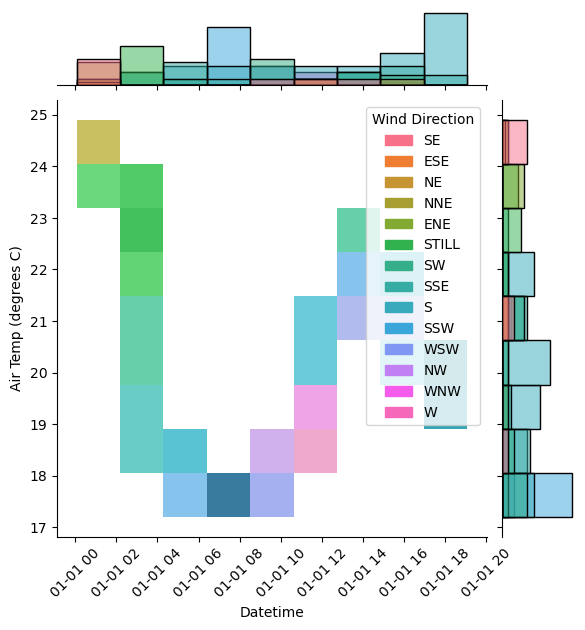

In [49]:
sns.jointplot(data=melb2, x="Datetime", y="Air Temp (degrees C)", hue="Wind Direction", kind="hist")
plt.xticks(rotation=45)

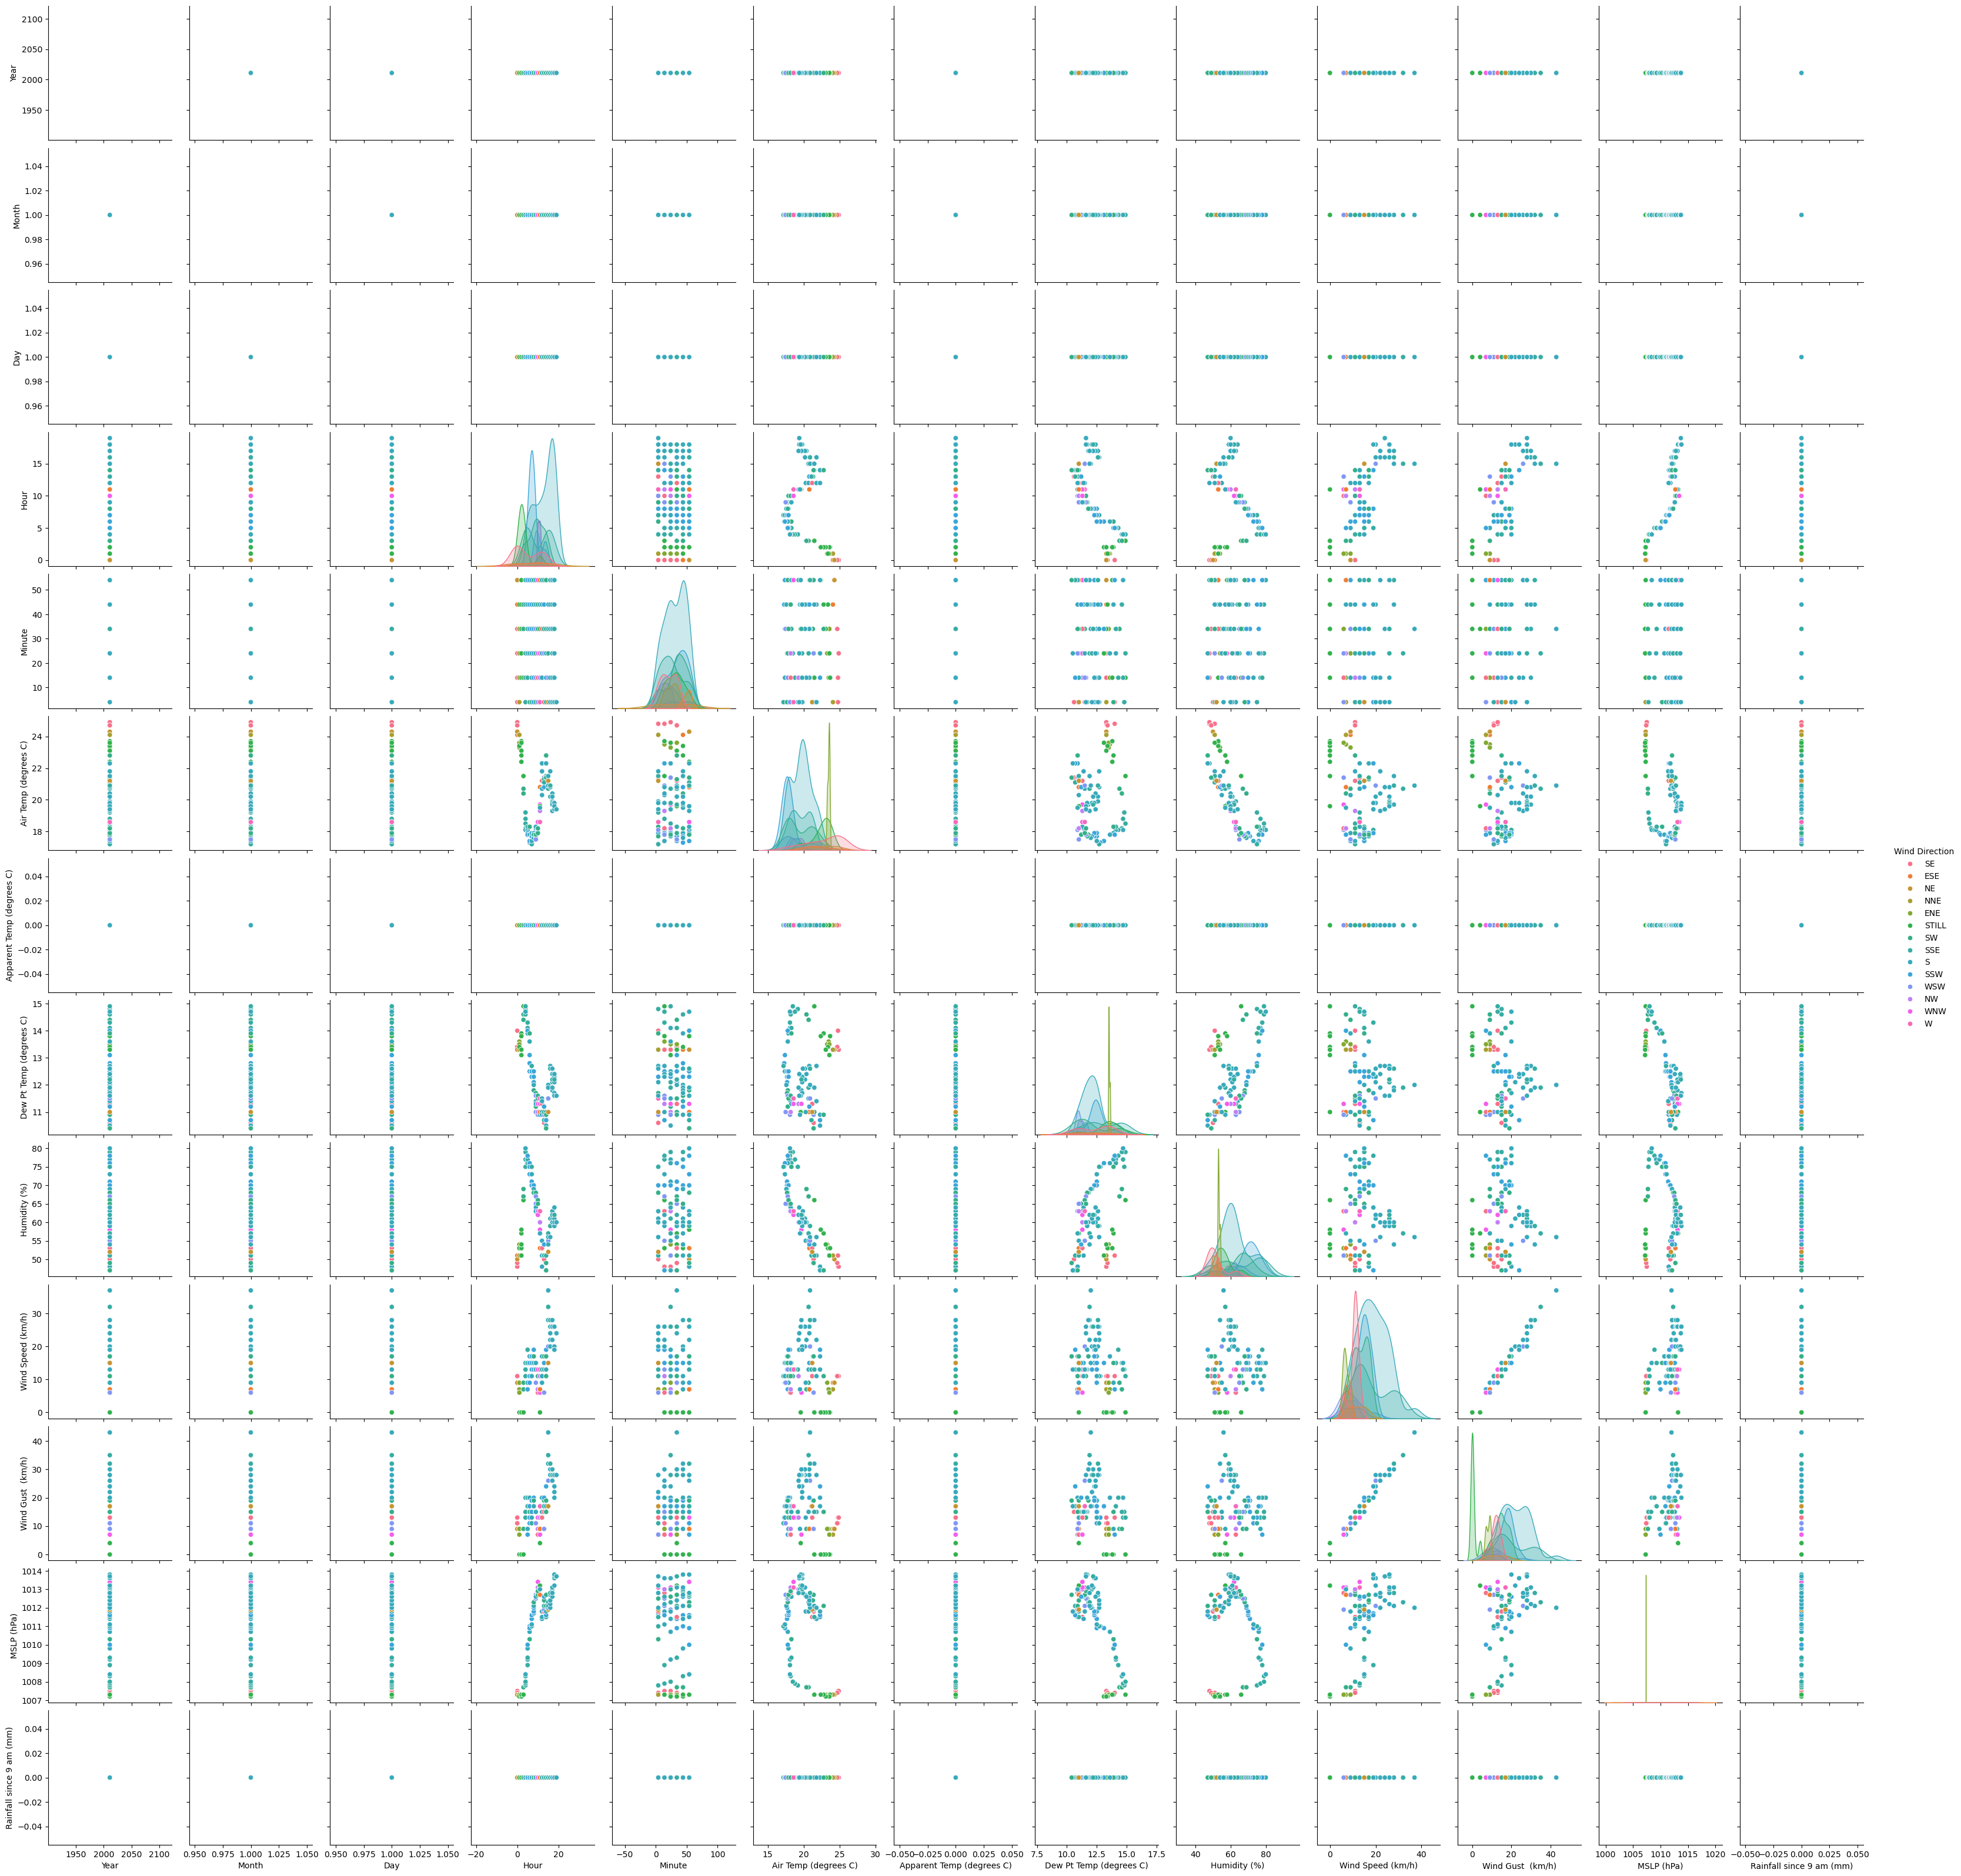

In [50]:
sns.pairplot(data=melb2, hue="Wind Direction")


In [51]:
melb3 = melb.iloc[::,5:]

In [52]:
melb3

,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Datetime
0,24.8,0.0,14.0,51,SE,11.0,13.0,1007.4,0.0,2011-01-01 00:04:00
1,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
2,24.8,0.0,13.3,48,SE,11.0,11.0,1007.5,0.0,2011-01-01 00:14:00
3,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
4,24.9,0.0,13.3,48,SE,11.0,13.0,1007.5,0.0,2011-01-01 00:24:00
...,...,...,...,...,...,...,...,...,...,...
1113146,33.4,32.5,14.9,32,NW,20.0,35.0,1014.6,0.0,2025-03-12 15:30:00
1113147,33.5,32.9,14.5,31,NNW,26.0,41.0,1014.6,0.0,2025-03-12 15:34:00
1113148,34.4,34.2,14.8,30,WNW,26.0,41.0,1014.4,0.0,2025-03-12 16:00:00
1113149,33.6,32.4,14.1,30,WNW,26.0,41.0,1014.1,0.0,2025-03-12 16:30:00


(array([  6971.,  84091., 319043., 346105., 215175.,  85262.,  36452.,
         14956.,   4182.,    914.]),
 array([ 0.5,  4.8,  9.1, 13.4, 17.7, 22. , 26.3, 30.6, 34.9, 39.2, 43.5]),
 <BarContainer object of 10 artists>)

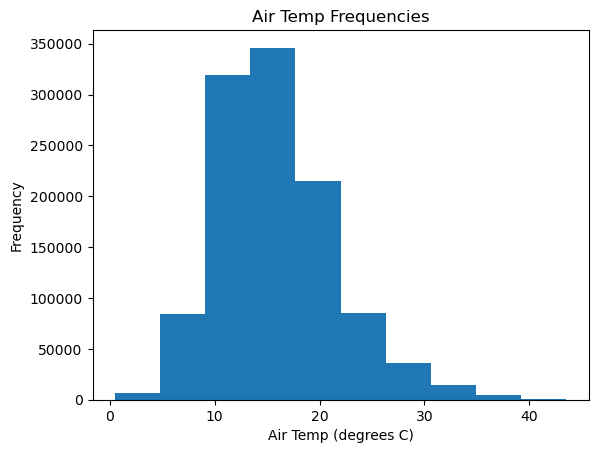

In [53]:
plt.title("Air Temp Frequencies")
plt.ylabel("Frequency")
plt.xlabel("Air Temp (degrees C)")
plt.hist(melb3["Air Temp (degrees C)"])

(array([1.068876e+06, 2.631700e+04, 9.426000e+03, 3.071000e+03,
        1.795000e+03, 1.214000e+03, 8.960000e+02, 5.490000e+02,
        4.240000e+02, 2.800000e+01]),
 array([ 0.  ,  5.46, 10.92, 16.38, 21.84, 27.3 , 32.76, 38.22, 43.68,
        49.14, 54.6 ]),
 <BarContainer object of 10 artists>)

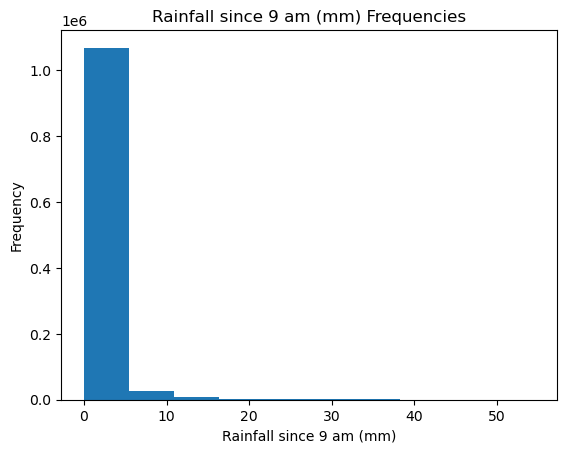

In [54]:
plt.title("Rainfall since 9 am (mm) Frequencies")
plt.ylabel("Frequency")
plt.xlabel("Rainfall since 9 am (mm)")
plt.hist(melb3["Rainfall since 9 am (mm)"])

In [55]:
air_month_av = melb.groupby(["Year", "Month"])["Air Temp (degrees C)"].mean().reset_index()


In [56]:
air_month_av = air_month_av.sort_values(["Year", "Month"])


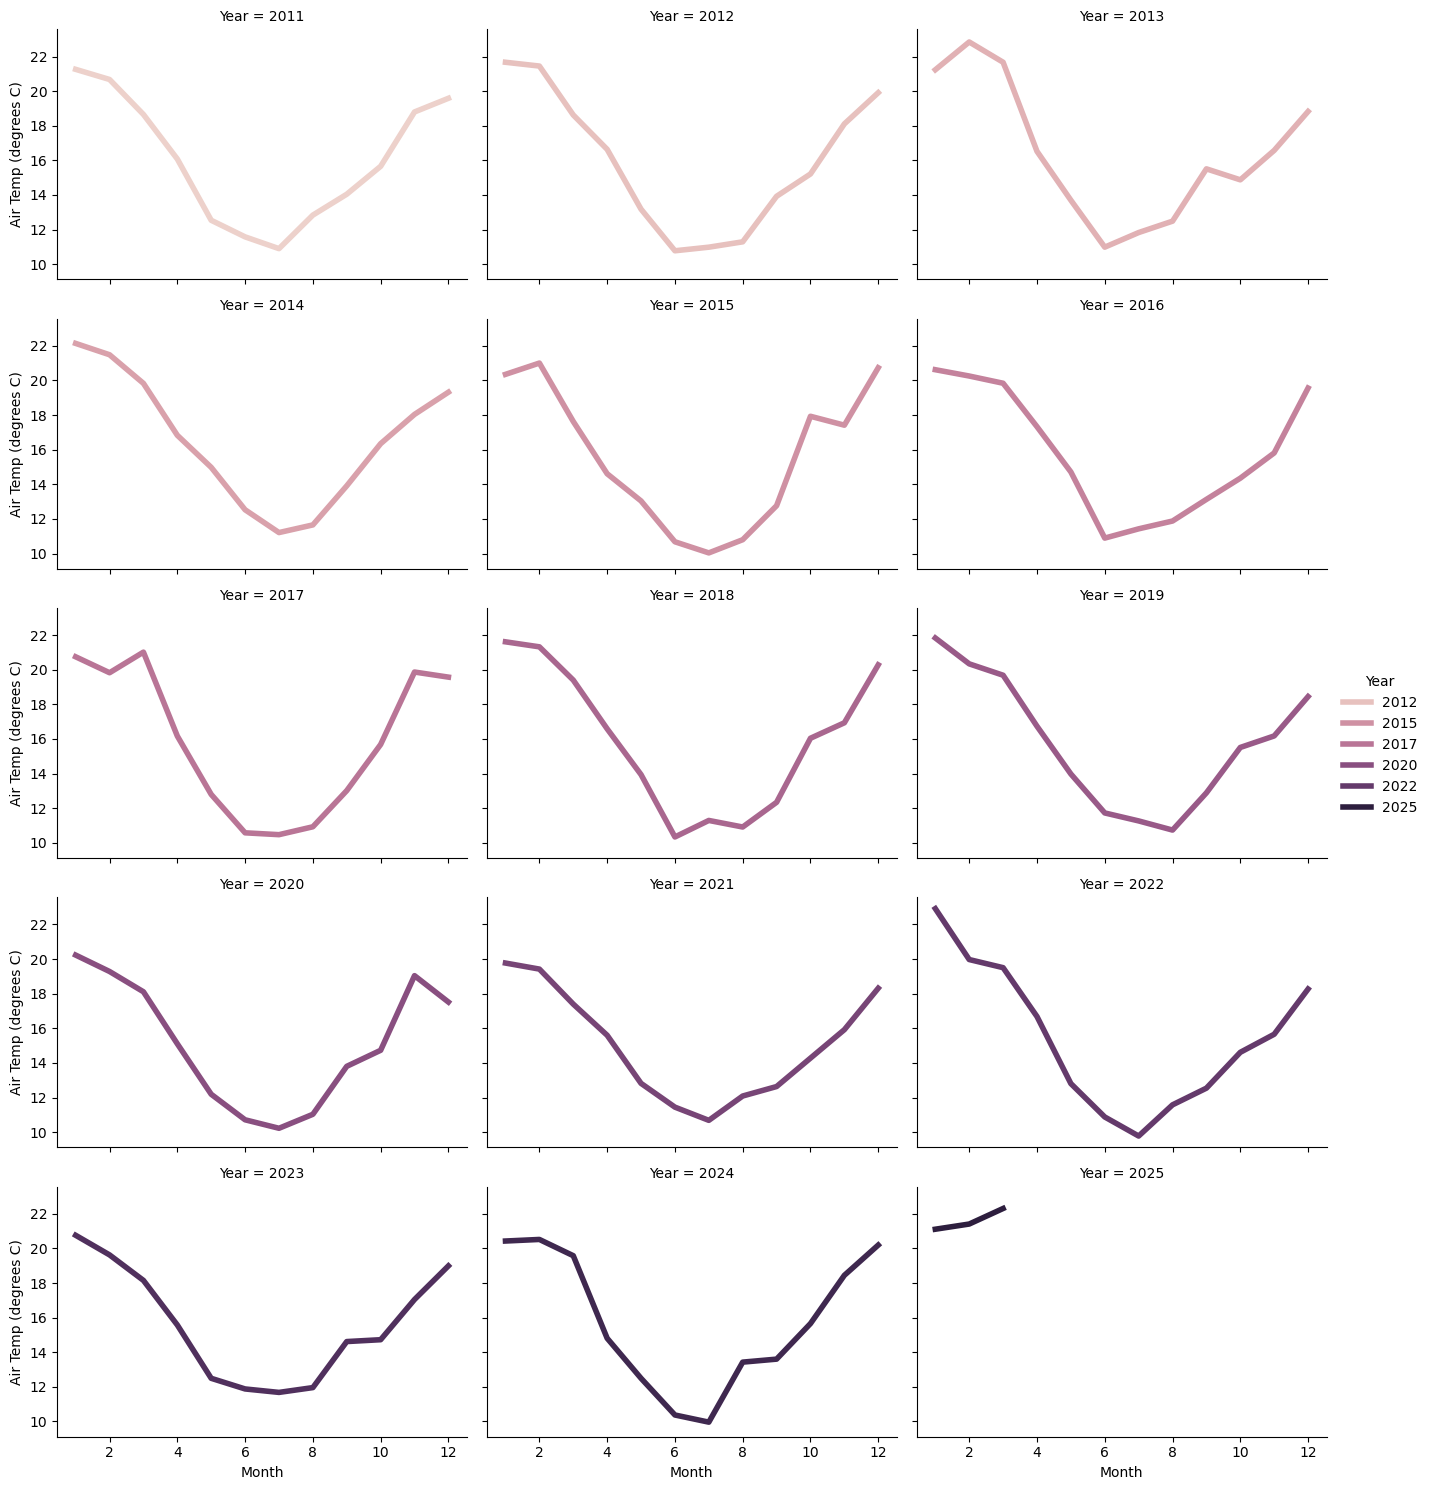

In [57]:
g1 = sns.relplot(
    data = air_month_av,
    x = "Month", y = "Air Temp (degrees C)", col = "Year",
    hue = "Year", kind = "line", linewidth = 4, zorder = 5,
    col_wrap = 3, height = 3, aspect=1.5, legend = True, 
)

### Average temperature by Month, from January 2011 to March 2025

The above line plots demonstrate that temperature is generally highest between December to February in Melbourne, with a mean temperature from 17 to 22 degrees C.

Between the months of May to September, mean temperatures are 16 degrees and lower. It demonstrates the expected Summer to Winter highs and lows.

In [58]:
melb_new = melb[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Air Temp (degrees C)', 'Humidity (%)', 'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Datetime']]

In [59]:
melb_new.loc[:,"Dew Pt Temp (degrees C)"] = melb_new.loc[:,'Air Temp (degrees C)'] - ((100-melb_new.loc[:,'Humidity (%)'])/5)

C:\Users\madis\AppData\Local\Temp\ipykernel_28588\1715486890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  melb_new.loc[:,"Dew Pt Temp (degrees C)"] = melb_new.loc[:,'Air Temp (degrees C)'] - ((100-melb_new.loc[:,'Humidity (%)'])/5)


In [60]:
# Apparent Temperature = actual temperature + 0.33(humidity) - 0.7(wind speed)  - 4

melb_new.loc[:,"Apparent Temp (degrees C)"] = melb_new.loc[:, "Air Temp (degrees C)"] + (0.33 * melb_new.loc[:, "Humidity (%)"]) - (0.7 * melb_new.loc[:, "Wind Speed (km/h)"]) - 4


# Some of the apparent temeratures feel suspciously high?

In [61]:
# What I have an issue with is that there are entries with duplicate times? Perhaps by making indiividual hourly and minutely groupbys this would be fixed?
# Things to be able to visualise
    # Create a new dataframe using the hot encoding for Wind Direction, creating a new binary column for each different direction, making a 0 or 1 entry if False or True.as_integer_ratio
minutely_stats = melb_new.groupby(["Year", "Month", "Day", "Hour", 'Minute'])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()

hourly_stats = melb_new.groupby(["Year", "Month", "Day", "Hour"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()
daily_stats = melb_new.groupby(["Year", "Month", "Day"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()

monthly_stats = melb_new.groupby(["Year", "Month"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)','Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()

yearly_stats = melb_new.groupby(["Year"])[["Air Temp (degrees C)", "Humidity (%)",'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)','Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)']].mean().reset_index()



In [62]:
# Need to think about how to manage duplicates with the Wind Direction column?
    # Perhaps I 

minutely_stats2 = melb_new.groupby(["Datetime"]).agg(air_temp = ("Air Temp (degrees C)", "mean"), hum = ("Humidity (%)", "mean"), wind_speed = ('Wind Speed (km/h)', 'mean'), wind_gust = ('Wind Gust  (km/h)', 'mean'),
       pre = ('MSLP (hPa)', 'mean'), rain = ('Rainfall since 9 am (mm)', 'mean'), app_temp = ('Apparent Temp (degrees C)', 'mean'), dew_temp = ('Dew Pt Temp (degrees C)', 'mean'), wind_di = ("Wind Direction", lambda x: None if len(x.mode()) == 0 else x.mode().iloc[0])).reset_index()

new_stats = melb_new.groupby(["Year", "Month", "Day", "Hour", 'Minute', "Datetime"]).agg(air_temp = ("Air Temp (degrees C)", "mean"), hum = ("Humidity (%)", "mean"), wind_speed = ('Wind Speed (km/h)', 'mean'), wind_gust = ('Wind Gust  (km/h)', 'mean'),
       pre = ('MSLP (hPa)', 'mean'), rain = ('Rainfall since 9 am (mm)', 'mean'), app_temp = ('Apparent Temp (degrees C)', 'mean'), dew_temp = ('Dew Pt Temp (degrees C)', 'mean'), wind_di = ("Wind Direction", lambda x: None if len(x.mode()) == 0 else x.mode().iloc[0])).reset_index()

In [63]:
new_stats

,Year,Month,Day,Hour,Minute,Datetime,air_temp,hum,wind_speed,wind_gust,pre,rain,app_temp,dew_temp,wind_di
0,2011,1,1,0,4,2011-01-01 00:04:00,24.8,51.0,11.0,13.0,1007.4,0.0,29.93,15.0,SE
1,2011,1,1,0,14,2011-01-01 00:14:00,24.8,48.0,11.0,11.0,1007.5,0.0,28.94,14.4,SE
2,2011,1,1,0,24,2011-01-01 00:24:00,24.9,48.0,11.0,13.0,1007.5,0.0,29.04,14.5,SE
3,2011,1,1,0,34,2011-01-01 00:34:00,24.7,49.0,11.0,11.0,1007.4,0.0,29.17,14.5,SE
4,2011,1,1,0,44,2011-01-01 00:44:00,24.1,51.0,9.0,9.0,1007.3,0.0,30.63,14.3,ESE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568153,2025,3,12,15,5,2025-03-12 15:05:00,32.8,33.0,20.0,35.0,1015.0,0.0,25.69,19.4,NW
568154,2025,3,12,15,30,2025-03-12 15:30:00,33.4,32.0,20.0,35.0,1014.6,0.0,25.96,19.8,NW
568155,2025,3,12,15,34,2025-03-12 15:34:00,33.5,31.0,26.0,41.0,1014.6,0.0,21.53,19.7,NNW
568156,2025,3,12,16,0,2025-03-12 16:00:00,34.4,30.0,26.0,41.0,1014.4,0.0,22.10,20.4,WNW


In [64]:
directionality_table = {'N': 0,
                        'NNE': 1,
                        'NE': 2,
                        'ENE': 3,
                        'E': 4,
                        'ESE': 5,
                        'SE': 6,
                        'SSE': 7,
                        'S': 8,
                        'SSW': 9,
                        'SW': 10,
                        'WSW': 11,
                        'W': 12,
                        'WNW': 13,
                        'NW': 14,
                        'NNW': 15,
                        'STILL': None
}

In [65]:
# new_stats["Num Direction"] = new_stats["wind_di"].replace(directionality_table)
# new_stats["Degree Direction"] = new_stats["Num Direction"] * 22.5
# new_stats["Vector Direction"] = np.tan(new_stats["Degree Direction"]*180/np.pi)
# new_stats["lat"] = -37.6707
# new_stats['long'] = 144.8379 # (latitude, longitude)

In [66]:
new_stats

,Year,Month,Day,Hour,Minute,Datetime,air_temp,hum,wind_speed,wind_gust,pre,rain,app_temp,dew_temp,wind_di
0,2011,1,1,0,4,2011-01-01 00:04:00,24.8,51.0,11.0,13.0,1007.4,0.0,29.93,15.0,SE
1,2011,1,1,0,14,2011-01-01 00:14:00,24.8,48.0,11.0,11.0,1007.5,0.0,28.94,14.4,SE
2,2011,1,1,0,24,2011-01-01 00:24:00,24.9,48.0,11.0,13.0,1007.5,0.0,29.04,14.5,SE
3,2011,1,1,0,34,2011-01-01 00:34:00,24.7,49.0,11.0,11.0,1007.4,0.0,29.17,14.5,SE
4,2011,1,1,0,44,2011-01-01 00:44:00,24.1,51.0,9.0,9.0,1007.3,0.0,30.63,14.3,ESE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568153,2025,3,12,15,5,2025-03-12 15:05:00,32.8,33.0,20.0,35.0,1015.0,0.0,25.69,19.4,NW
568154,2025,3,12,15,30,2025-03-12 15:30:00,33.4,32.0,20.0,35.0,1014.6,0.0,25.96,19.8,NW
568155,2025,3,12,15,34,2025-03-12 15:34:00,33.5,31.0,26.0,41.0,1014.6,0.0,21.53,19.7,NNW
568156,2025,3,12,16,0,2025-03-12 16:00:00,34.4,30.0,26.0,41.0,1014.4,0.0,22.10,20.4,WNW


In [67]:
# # equation for the positional change after 30 mins
# #     x' = 0.5 * s * (x cos(angle) +
#     # y' = 0.5 * ysin(angle))
    
# plt.ylabel("Latitude")
# plt.xlabel("Longitude")
# plt.title("Wind Map (30 mins)")
# for i in range(new_stats.shape[0]):
#     # x = [new_stats[i,"long"], 0.5 * new_stats['wind_speed'] *((new_stats[i,"long"] * np.cos(new_stats["Degree Direction"] * 180/np.pi)) + (new_stats[i,"lat"] * np.sin(new_stats["Degree Direction"])))]
#     x = [new_stats.loc[i, 'long'], 0.5 * new_stats.loc[i, 'wind_speed'] * np.cos(new_stats.loc[i, 'Degree Direction'] * np.pi/180) + new_stats.loc[i, 'long']]
#     y = [new_stats.loc[i, 'lat'], 0.5 * new_stats.loc[i, 'wind_speed'] * np.sin(new_stats.loc[i, 'Degree Direction'] * np.pi/180) + new_stats.loc[i, 'lat']]
#     plt.plot(x, y, marker = 'o')

In [68]:
# arrow_visualisation = new_stats[['wind_speed', 'long', 'lat', 'Degree Direction']]

In [69]:
# theta = np.deg2rad(270-new_stats['Degree Direction'])
# arrow_visualisation["lat2"] = 0.5 * new_stats['wind_speed'] * np.sin(theta)
# arrow_visualisation["long2"] = 0.5 * new_stats['wind_speed'] * np.cos(theta)

In [70]:

# print(arrow_visualisation.describe())

In [71]:
# # plot the arrow diagram

# # for day in range(len())
# arrow_visualisation2 = arrow_visualisation.iloc[0:10001,::]
# plt.figure(figsize = (24,12))
# Q = plt.quiver(arrow_visualisation2["long"], arrow_visualisation2['lat'], arrow_visualisation2['long2'],arrow_visualisation2['lat2'],
#         arrow_visualisation2['wind_speed'],
#         scale = 10, 
#         angles='xy',
#         scale_units='xy',
#         width=0.004,
#         headlength=2,
#         cmap = 'plasma_r')
# cbar = plt.colorbar(Q, label='wind_speed')
# plt.show()

In [72]:
new_stats

,Year,Month,Day,Hour,Minute,Datetime,air_temp,hum,wind_speed,wind_gust,pre,rain,app_temp,dew_temp,wind_di
0,2011,1,1,0,4,2011-01-01 00:04:00,24.8,51.0,11.0,13.0,1007.4,0.0,29.93,15.0,SE
1,2011,1,1,0,14,2011-01-01 00:14:00,24.8,48.0,11.0,11.0,1007.5,0.0,28.94,14.4,SE
2,2011,1,1,0,24,2011-01-01 00:24:00,24.9,48.0,11.0,13.0,1007.5,0.0,29.04,14.5,SE
3,2011,1,1,0,34,2011-01-01 00:34:00,24.7,49.0,11.0,11.0,1007.4,0.0,29.17,14.5,SE
4,2011,1,1,0,44,2011-01-01 00:44:00,24.1,51.0,9.0,9.0,1007.3,0.0,30.63,14.3,ESE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568153,2025,3,12,15,5,2025-03-12 15:05:00,32.8,33.0,20.0,35.0,1015.0,0.0,25.69,19.4,NW
568154,2025,3,12,15,30,2025-03-12 15:30:00,33.4,32.0,20.0,35.0,1014.6,0.0,25.96,19.8,NW
568155,2025,3,12,15,34,2025-03-12 15:34:00,33.5,31.0,26.0,41.0,1014.6,0.0,21.53,19.7,NNW
568156,2025,3,12,16,0,2025-03-12 16:00:00,34.4,30.0,26.0,41.0,1014.4,0.0,22.10,20.4,WNW


In [73]:

month_key = new_stats.groupby(pd.Grouper(key='Datetime', freq = 'M')).mean(numeric_only=True)
quarter_key = new_stats.groupby(pd.Grouper(key='Datetime', freq = '3M')).mean(numeric_only=True)

([<matplotlib.axis.XTick at 0x19b981bbc40>,
 [Text(15005.0, 0, '2011-01-31'),
  Text(15370.0, 0, '2012-01-31'),
  Text(15736.0, 0, '2013-01-31'),
  Text(16101.0, 0, '2014-01-31'),
  Text(16466.0, 0, '2015-01-31'),
  Text(16831.0, 0, '2016-01-31'),
  Text(17197.0, 0, '2017-01-31'),
  Text(17562.0, 0, '2018-01-31'),
  Text(17927.0, 0, '2019-01-31'),
  Text(18292.0, 0, '2020-01-31'),
  Text(18658.0, 0, '2021-01-31'),
  Text(19023.0, 0, '2022-01-31'),
  Text(19388.0, 0, '2023-01-31'),
  Text(19753.0, 0, '2024-01-31'),
  Text(20119.0, 0, '2025-01-31')])

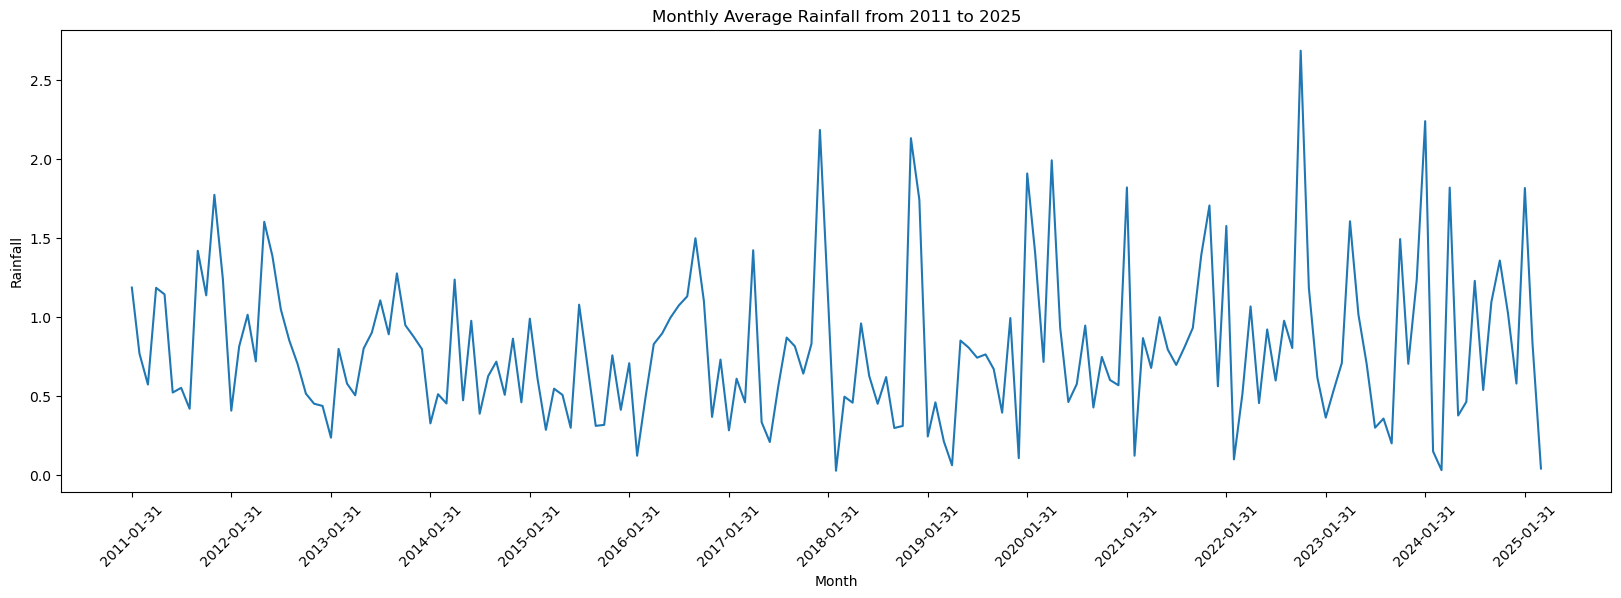

In [74]:
fig = plt.subplots(figsize = (20,6))
plt.title("Monthly Average Rainfall from 2011 to 2025")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.plot(month_key["rain"])
plt.xticks(month_key.index[::12],rotation=45)

([<matplotlib.axis.XTick at 0x19b9810f4f0>,
 [Text(15005.0, 0, '2011-01-31'),
  Text(15186.0, 0, '2011-07-31'),
  Text(15370.0, 0, '2012-01-31'),
  Text(15552.0, 0, '2012-07-31'),
  Text(15736.0, 0, '2013-01-31'),
  Text(15917.0, 0, '2013-07-31'),
  Text(16101.0, 0, '2014-01-31'),
  Text(16282.0, 0, '2014-07-31'),
  Text(16466.0, 0, '2015-01-31'),
  Text(16647.0, 0, '2015-07-31'),
  Text(16831.0, 0, '2016-01-31'),
  Text(17013.0, 0, '2016-07-31'),
  Text(17197.0, 0, '2017-01-31'),
  Text(17378.0, 0, '2017-07-31'),
  Text(17562.0, 0, '2018-01-31'),
  Text(17743.0, 0, '2018-07-31'),
  Text(17927.0, 0, '2019-01-31'),
  Text(18108.0, 0, '2019-07-31'),
  Text(18292.0, 0, '2020-01-31'),
  Text(18474.0, 0, '2020-07-31'),
  Text(18658.0, 0, '2021-01-31'),
  Text(18839.0, 0, '2021-07-31'),
  Text(19023.0, 0, '2022-01-31'),
  Text(19204.0, 0, '2022-07-31'),
  Text(19388.0, 0, '2023-01-31'),
  Text(19569.0, 0, '2023-07-31'),
  Text(19753.0, 0, '2024-01-31'),
  Text(19935.0, 0, '2024-07-31'),
  Te

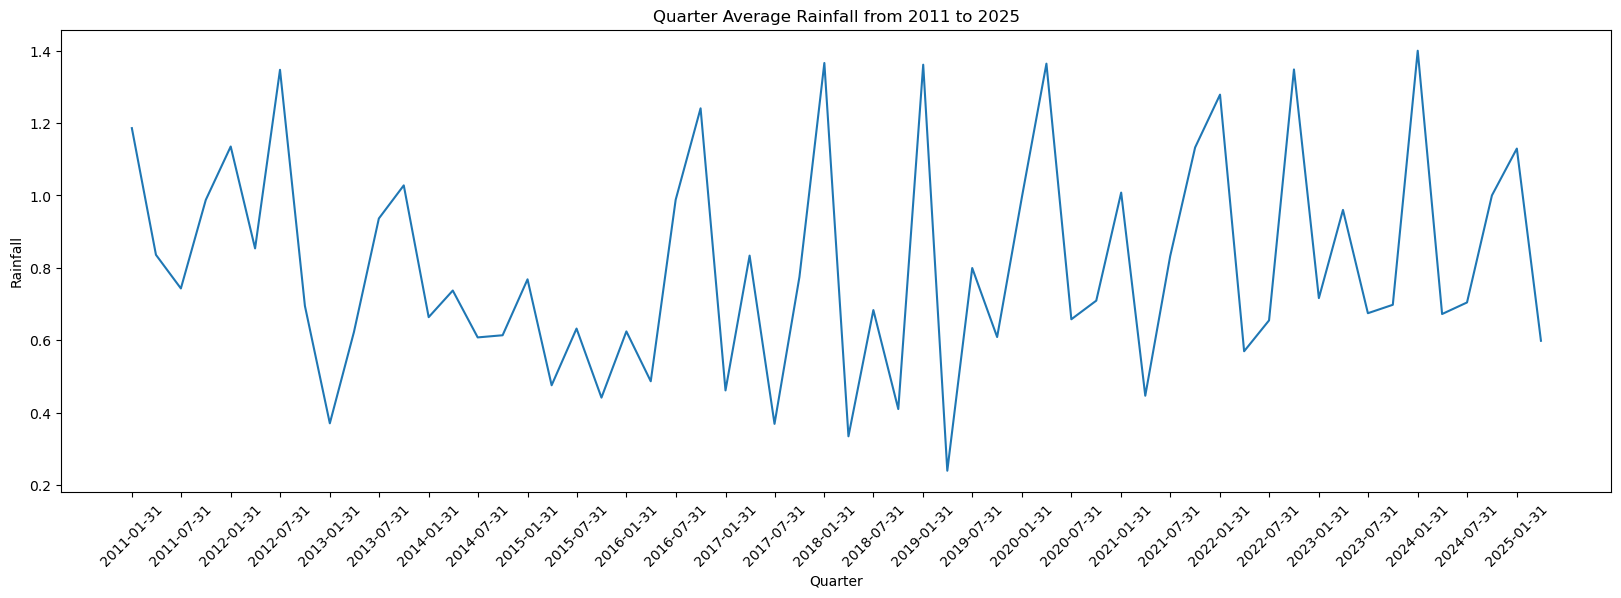

In [75]:
fig2 = plt.subplots(figsize = (20,6))
plt.title("Quarter Average Rainfall from 2011 to 2025")
plt.xlabel("Quarter")
plt.ylabel("Rainfall")
plt.plot(quarter_key["rain"])
plt.xticks(quarter_key.index[::2],rotation=45)

In [76]:
monthly_stats.columns

Index(['Year', 'Month', 'Air Temp (degrees C)', 'Humidity (%)',
       'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'MSLP (hPa)',
       'Rainfall since 9 am (mm)', 'Apparent Temp (degrees C)',
       'Dew Pt Temp (degrees C)'],
      dtype='object')

In [77]:
monthly2 = monthly_stats[["Month", "Air Temp (degrees C)", "Humidity (%)", "Wind Speed (km/h)", "Wind Gust  (km/h)", "Rainfall since 9 am (mm)", "Apparent Temp (degrees C)", "Dew Pt Temp (degrees C)"]].groupby("Month").mean()
monthly3 = new_stats[["Year", "Month", "Day", "rain"]].groupby(["Year", "Month", "Day"]).max()


monthly_average_sum = new_stats.set_index("Datetime", inplace=False)["rain"].resample("D").max().resample("M").sum().groupby(lambda x: x.month).mean()


In [78]:
daily_rain = new_stats.set_index("Datetime", inplace=False)["rain"].resample("D").max()

In [79]:
daily_rain

Datetime
2011-01-01    0.0
2011-01-02    0.0
2011-01-03    0.0
2011-01-04    0.0
2011-01-05    0.0
             ... 
2025-03-08    0.0
2025-03-09    0.0
2025-03-10    1.8
2025-03-11    0.0
2025-03-12    0.0
Freq: D, Name: rain, Length: 5185, dtype: float64

<BarContainer object of 12 artists>

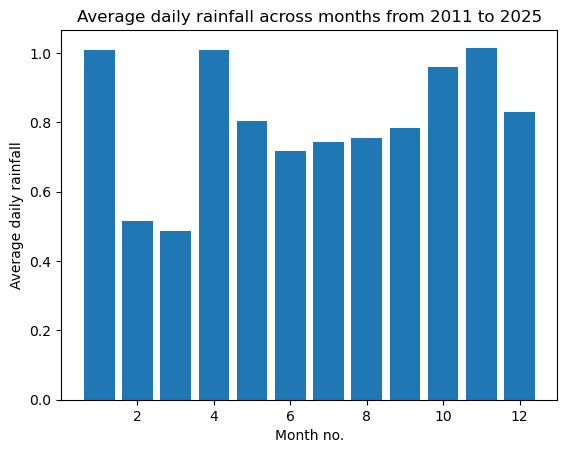

In [80]:
# plt.bar(monthly2.index, monthly2["Air Temp (degrees C)"])
plt.title("Average daily rainfall across months from 2011 to 2025")
plt.xlabel("Month no.")
plt.ylabel("Average daily rainfall")
plt.bar(monthly2.index, monthly2["Rainfall since 9 am (mm)"])

Text(0, 0.5, 'Average total rain')

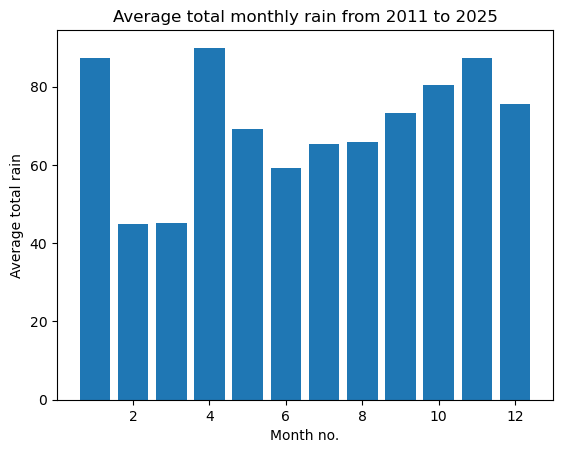

In [81]:
plt.bar(monthly_average_sum.index, monthly_average_sum)
plt.title("Average total monthly rain from 2011 to 2025")
plt.xlabel("Month no.")
plt.ylabel("Average total rain")

In [82]:
from statsmodels.tsa.arima_model import ARIMA


In [83]:
new_stats

,Year,Month,Day,Hour,Minute,Datetime,air_temp,hum,wind_speed,wind_gust,pre,rain,app_temp,dew_temp,wind_di
0,2011,1,1,0,4,2011-01-01 00:04:00,24.8,51.0,11.0,13.0,1007.4,0.0,29.93,15.0,SE
1,2011,1,1,0,14,2011-01-01 00:14:00,24.8,48.0,11.0,11.0,1007.5,0.0,28.94,14.4,SE
2,2011,1,1,0,24,2011-01-01 00:24:00,24.9,48.0,11.0,13.0,1007.5,0.0,29.04,14.5,SE
3,2011,1,1,0,34,2011-01-01 00:34:00,24.7,49.0,11.0,11.0,1007.4,0.0,29.17,14.5,SE
4,2011,1,1,0,44,2011-01-01 00:44:00,24.1,51.0,9.0,9.0,1007.3,0.0,30.63,14.3,ESE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568153,2025,3,12,15,5,2025-03-12 15:05:00,32.8,33.0,20.0,35.0,1015.0,0.0,25.69,19.4,NW
568154,2025,3,12,15,30,2025-03-12 15:30:00,33.4,32.0,20.0,35.0,1014.6,0.0,25.96,19.8,NW
568155,2025,3,12,15,34,2025-03-12 15:34:00,33.5,31.0,26.0,41.0,1014.6,0.0,21.53,19.7,NNW
568156,2025,3,12,16,0,2025-03-12 16:00:00,34.4,30.0,26.0,41.0,1014.4,0.0,22.10,20.4,WNW


In [84]:
# Use Augmented Dicky-Fuller test to check for stationarity
from statsmodels.tsa.stattools import adfuller
# arima_set = new_stats.iloc[:,:14].dropna(subset=["rain", "app_temp", "wind_speed", "wind_gust", "pre"]) # test dropping rain



In [85]:
daily_rain2 = daily_rain.dropna(inplace=False, axis = 0)
# arima_set2 = new_stats.iloc[:,[5,11]].dropna(inplace=False) # test dropping rain


In [86]:
# adf_test = adfuller(arima_set["rain"])
adf_test2 = adfuller(daily_rain2)


In [87]:
# above values imply that the data is highly stationary

# adf statistic is highly negative --> 

In [88]:
print(adf_test2)

(-30.02140513374497, 0.0, 4, 5178, {'1%': -3.431613527376366, '5%': -2.8620983466944008, '10%': -2.567067207896378}, 30354.596137683573)


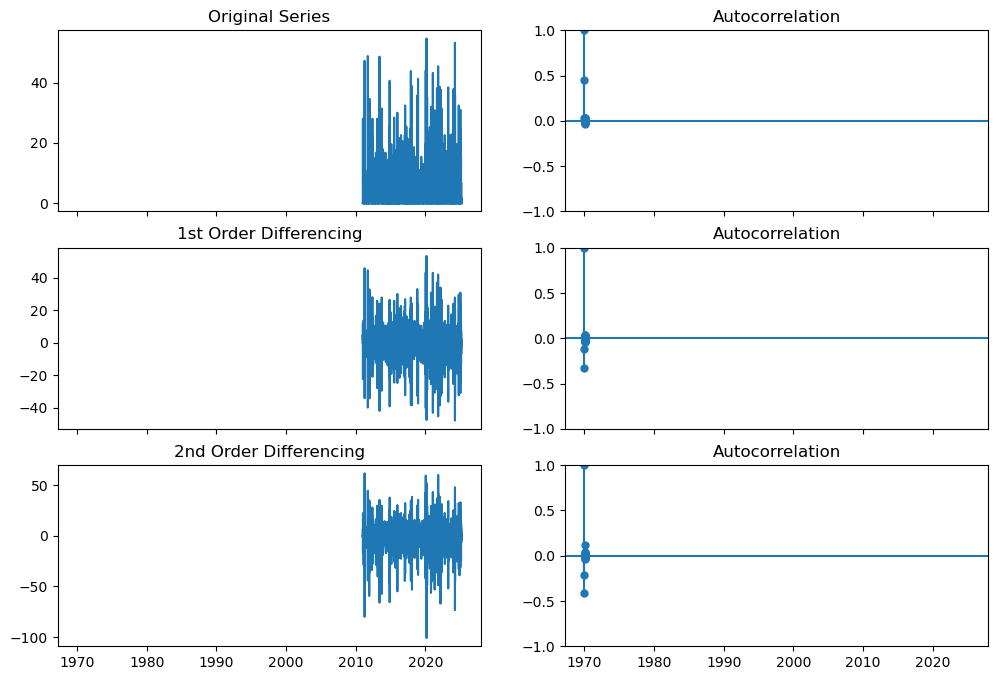

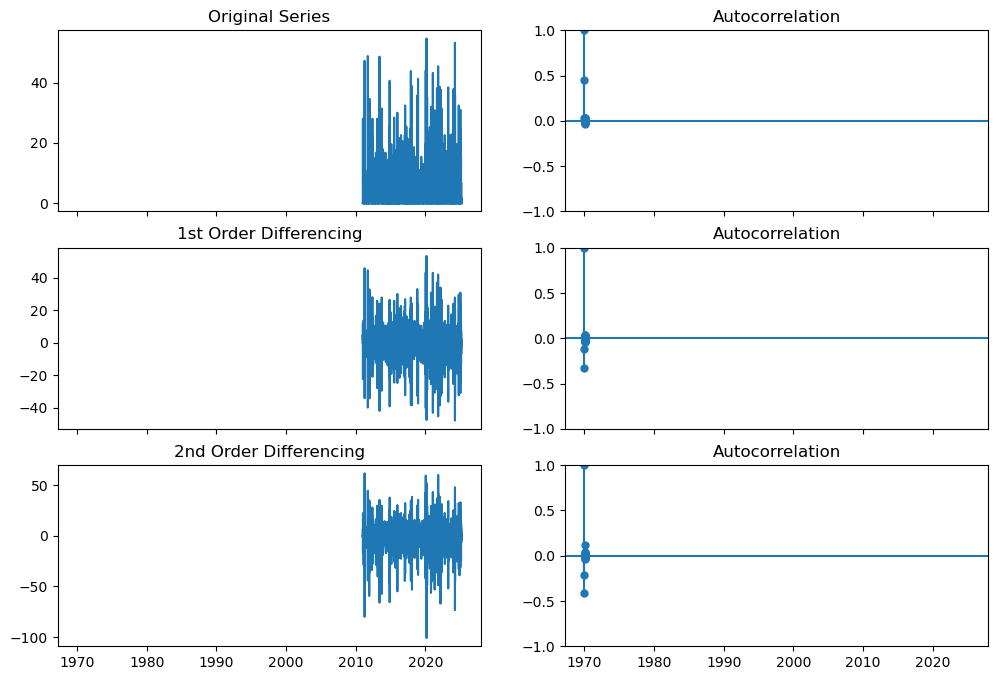

In [89]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, sharex=True, figsize = (12,8))
axes[0, 0].plot(daily_rain2); axes[0, 0].set_title('Original Series')
plot_acf(daily_rain2, ax=axes[0, 1])

axes[1, 0].plot(daily_rain2.diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(daily_rain2.diff().dropna(), ax=axes[1, 1])


axes[2, 0].plot(daily_rain2.diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(daily_rain2.diff().diff().dropna(), ax=axes[2, 1])

In [90]:
from pmdarima import auto_arima

Text(0.5, 0, 'Time')

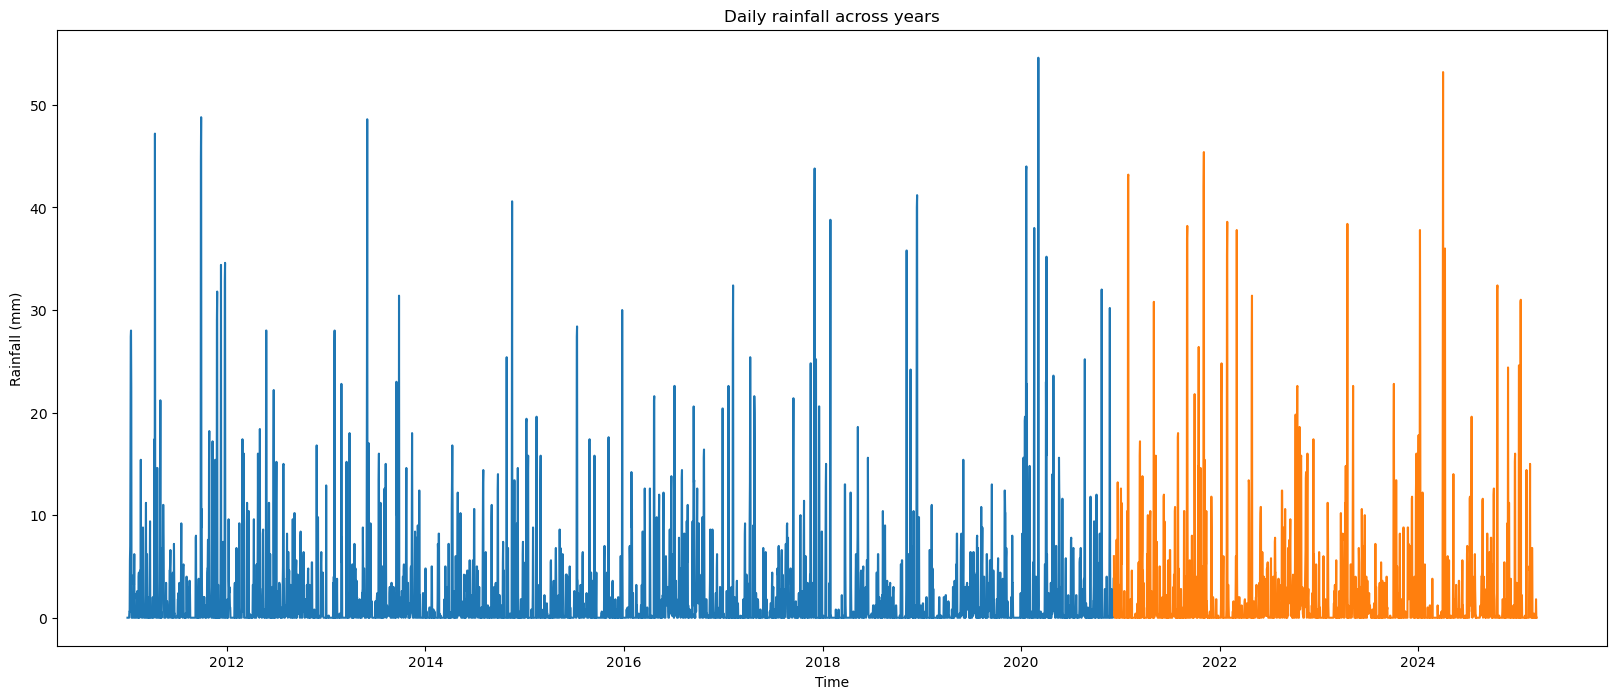

In [91]:
daily_rain2 = daily_rain2.dropna(inplace=False).asfreq("D")
daily_rain2.index = pd.to_datetime(daily_rain2.index)
train = daily_rain2[:int(0.7*len(daily_rain2))].dropna()
train_tf = np.log1p(train)
test = daily_rain2[int(0.7*len(daily_rain2)):].dropna()
# train = train.asfreq('D')   # or 'H' depending on your data
# test = test.asfreq('D')

train = train.dropna(inplace=False)
# print(train.isna().sum())
# print(test.isna().sum())
plt.figure(figsize=(20,8))
plt.plot(train)
plt.plot(test)
plt.title("Daily rainfall across years")
plt.ylabel("Rainfall (mm)")
plt.xlabel("Time")


In [92]:
model2 = auto_arima(
    train_tf,
    start_p = 0,
    start_q = 0,
    max_p = 5,
    seasonal = True,
    m = 7,
    error_action = "warn",
    trace = True,
    stepwise = True,
    random_state = 20,
    n_fits = 20)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=9377.518, Time=1.86 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=9376.318, Time=0.30 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=8369.567, Time=0.81 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=8156.350, Time=0.92 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=10883.029, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=8155.320, Time=0.32 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=8156.321, Time=0.77 sec
 ARIMA(0,0,1)(1,0,1)[7] intercept   : AIC=8159.292, Time=0.90 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AIC=8125.981, Time=0.46 sec
 ARIMA(1,0,1)(1,0,0)[7] intercept   : AIC=8127.665, Time=0.94 sec
 ARIMA(1,0,1)(0,0,1)[7] intercept   : AIC=8127.672, Time=0.90 sec
 ARIMA(1,0,1)(1,0,1)[7] intercept   : AIC=8129.971, Time=1.37 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=8367.818, Time=0.28 sec
 ARIMA(2,0,1)(0,0,0)[7] intercept   : AIC=8127.386, Time=0.81 sec
 ARIMA(1,0,2)(0,0,0)[7] intercep

In [93]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 3627
Model:               SARIMAX(0, 0, 2)   Log Likelihood               -4058.882
Date:                Mon, 27 Apr 2026   AIC                           8125.763
Time:                        23:45:46   BIC                           8150.548
Sample:                             0   HQIC                          8134.593
                               - 3627                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6327      0.031     20.512      0.000       0.572       0.693
ma.L1          0.6349      0.017     36.904      0.000       0.601       0.669
ma.L2          0.0933      0.016      5.817      0.000       0.062       0.125
sigma2         0.5489      0.013     41.271      0.000       0.523       0.575
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1727.28
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               0.90   Skew:                             1.27
Prob(H) (two-sided):                  0.08   Kurtosis:                         5.22
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [97]:
n_periods = len(test)
# forcast = model.predict(n_periods = len(test))
# prediction = pd.DataFrame(forcast, index = test.index, columns = ["Prediction"] )
forcast = model2.predict(n_periods = len(test))
forcast = np.expm1(forcast)
# prediction2 = pd.DataFrame(prediction2, index = test.index, columns = ["Prediction2"] )

c:\Users\madis\anaconda3\envs\dataenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\madis\anaconda3\envs\dataenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


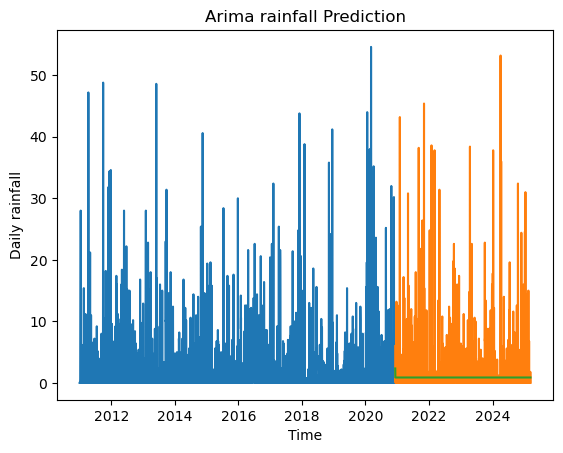

In [102]:
plt.title("Arima rainfall Prediction")
plt.ylabel("Daily rainfall")
plt.xlabel("Time")
plt.plot(train, label='Train')
plt.plot(test, label='Valid')
plt.plot(test.index,forcast,label='Prediction')